In [7]:
from neuromodes.waves import _gen_noise
from neuromodes.io import fetch_example_surf
from neuromodes import EigenSolver
#from nsbutils.plotting import plot_surf
from importlib.resources import files
from neuromodes.stats import cdistw
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags

In [2]:
solver = EigenSolver(fetch_example_surf(density='4k')[0]).solve(500)

In [4]:
noise0 = solver.emodes @ _gen_noise(n_samples=solver.n_modes, nt=100, seed=0)
noise1 = solver.emodes @ _gen_noise(n_samples=solver.n_modes, nt=100, seed=1)

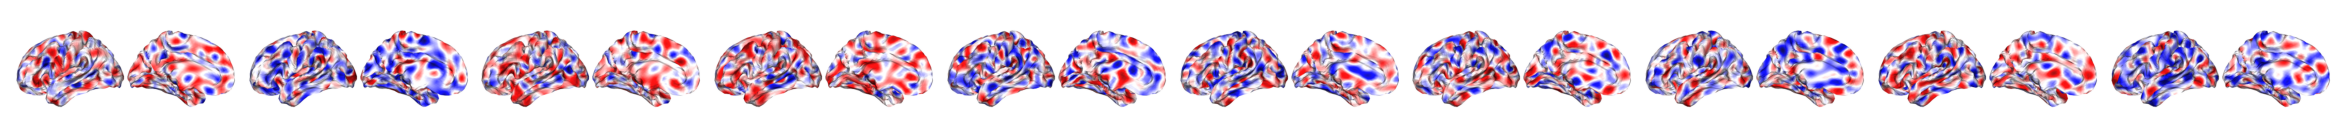

In [19]:
lh_surfpath = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-4k_hemi-L_midthickness.surf.gii'
plot_surf(lh_surfpath, data=noise0[:, ::10], cmap='seismic')

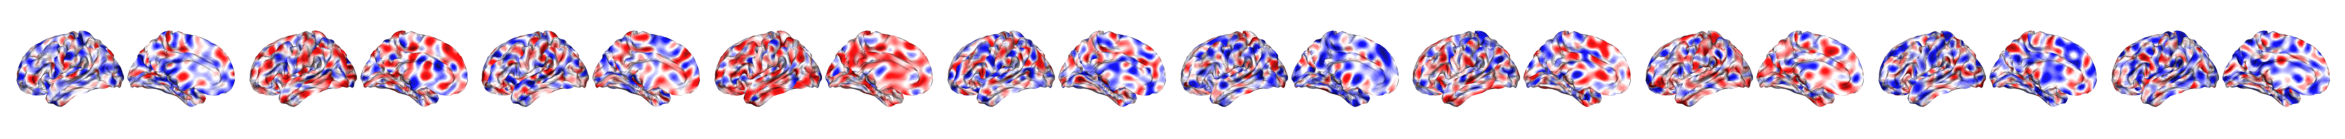

In [20]:
plot_surf(lh_surfpath, data=noise1[:, ::10], cmap='seismic')

In [21]:
waves0 = solver.sim_nft_waves(ext_input=noise0)
waves1 = solver.sim_nft_waves(ext_input=noise1)

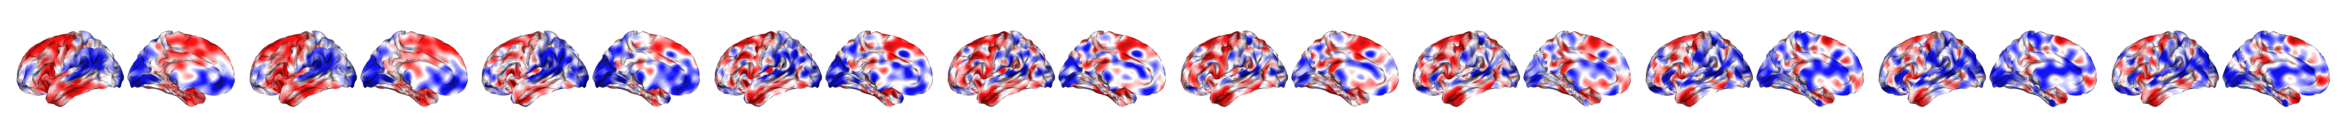

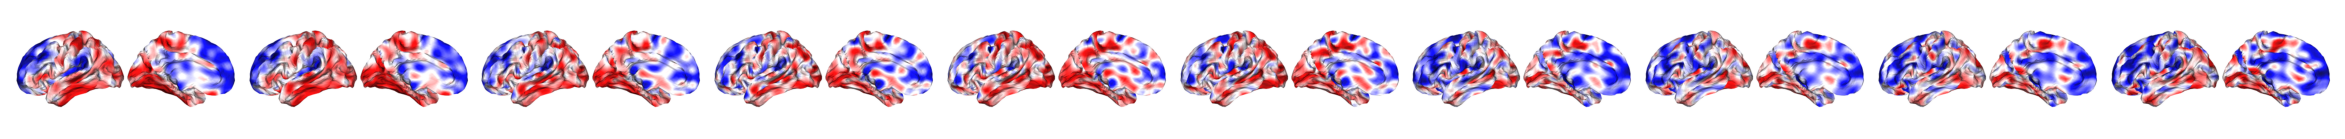

In [22]:
plot_surf(lh_surfpath, data=waves0[:, ::10], cmap='seismic')
plot_surf(lh_surfpath, data=waves1[:, ::10], cmap='seismic')

In [33]:
1-cdistw(waves0[:, 50], waves1[:, 50], solver.mass, metric='cosine')[0][0]

np.float64(-0.04256805208579695)

### Covariance

In [49]:
seed = 0
nt = 500

noise_modal = solver.emodes @ np.random.default_rng(0).standard_normal((solver.n_modes, nt))
cov_modal = (noise_modal.T @ solver.mass @ noise_modal)  # shape (nt, nt)
var_modal = np.diag(cov_modal)
cov_mean = np.mean(cov_modal[np.triu_indices_from(cov_modal, k=1)])
print(cov_mean)
var_modal.mean() - 500

0.04329872161554462


np.float64(0.9599938859926169)

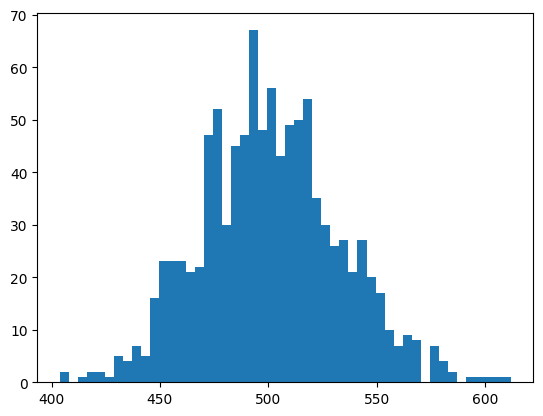

In [37]:
plt.hist(var_modal, bins=50)
plt.show()

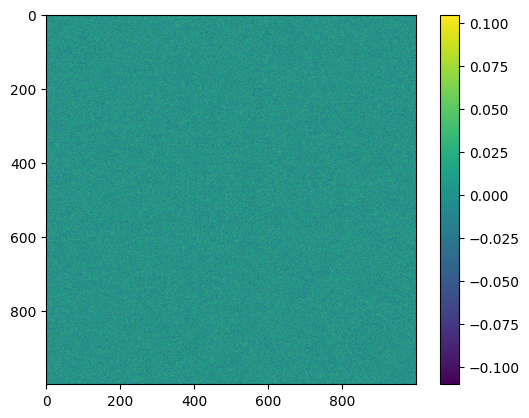

In [30]:
np.fill_diagonal(cov_modal, 0)
plt.imshow(cov_modal)
plt.colorbar()
plt.show()

In [15]:
# Try lumped mass
nt=500
mass_lumped = solver.compute_lbo(lump=True).mass
mass_inv = 1/mass_lumped.diagonal()[:, None]
noise = mass_inv * _gen_noise(solver.n_verts, nt, mass=mass_lumped, seed=0)
cov_mat = noise.T @ solver.mass @ noise
cov_mean = cov_mat[np.triu_indices_from(cov_mat, k=1)].mean()
var_mean = np.diag(cov_mat).mean()
print(cov_mean, var_mean)

-0.1610462284827294 4000.7258486914407


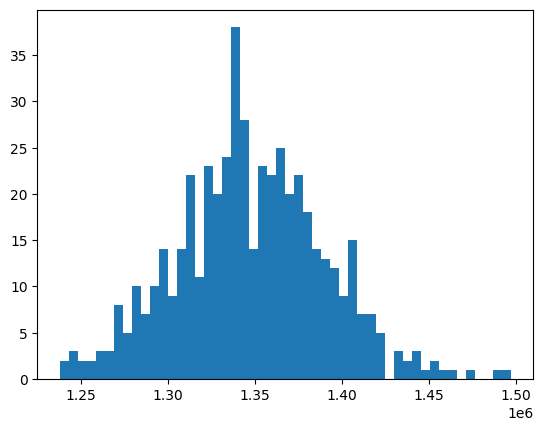

In [5]:
plt.hist(np.diag(cov_mat), bins=50)
plt.show()

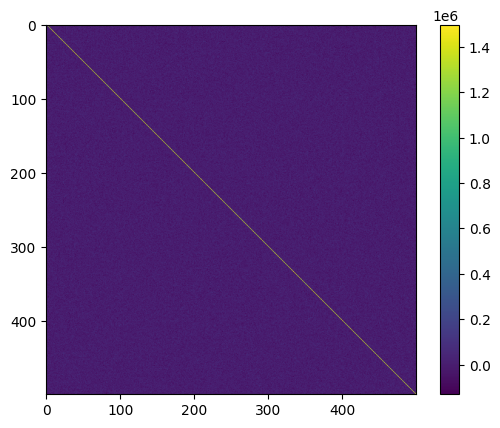

In [6]:
plt.imshow(cov_mat)
plt.colorbar()
plt.show()